# Notebook `dataloaders_v01.ipynb`: Construcción de DataLoaders para LSTM y TCN

**Fase CRISP-DM:** Modeling (Preparación de datos para Deep Learning)  
**Proyecto:** Predicción de tráfico en carretera mediante análisis de series temporales (M30)  
**Tutor:** Jesús Bonilla

## Objetivo del Notebook
Este cuaderno implementa la canalización de datos (*data pipeline*) que alimenta las arquitecturas de Deep Learning (LSTM y TCN). A partir de los tres conjuntos físicos generados por `split_data_v01.ipynb`, se realizan las transformaciones necesarias para producir objetos `DataLoader` de PyTorch listos para consumo directo en los notebooks de modelado.

El notebook **no entrena ningún modelo** ni guarda los DataLoaders en disco. Su función es definir la infraestructura reutilizable que cada notebook de modelo instanciará con sus propios hiperparámetros (ventana de entrada, horizonte de predicción, sensor objetivo, batch size).

## Decisiones Metodológicas y Flujo de Trabajo

### 1. Normalización con ajuste exclusivo en Train (`StandardScaler`)
* **Acción:** Ajuste del escalador únicamente sobre el conjunto de entrenamiento. Aplicación de la misma transformación (sin reajuste) a validación y test.
* **Justificación Académica:** Ajustar el escalador sobre los tres conjuntos conjuntamente introduciría *Data Leakage*: la red tendría acceso implícito a información estadística del futuro (media y desviación de val y test) durante el entrenamiento. El escalador ajustado se persiste en disco en formato `.pkl` para su uso en la fase de inferencia, donde es necesario aplicar la transformación inversa (`inverse_transform`) para recuperar los valores en unidades físicas (vehículos/hora) y calcular las métricas finales.

### 2. Codificación Cíclica de Variables Temporales (seno/coseno)
* **Acción:** Transformación de `hora` (período 24), `dia_semana` (período 7) y `mes` (período 12) a pares (sin, cos). Eliminación de las columnas ordinales originales.
* **Justificación Académica:** Las variables ordinales rompen la continuidad cíclica: bajo una codificación entera, el modelo percibiría que `hora=23` y `hora=0` son los instantes más distantes del día, cuando en realidad son adyacentes. La proyección trigonométrica coloca cada punto en un círculo unitario en el plano (sin, cos), preservando la continuidad en las transiciones de ciclo. Esta técnica es metodología estándar consolidada para series temporales con Deep Learning. Cada par queda escalado naturalmente en [−1, 1], lo que beneficia la convergencia del gradiente.
* **Vector de entrada resultante:** 12 columnas de señal normalizada + 6 columnas cíclicas + 1 binaria (`es_finde`) = **19 features por timestep**.

### 3. Clase `M30Dataset` con Ventana Deslizante y Filtrado de NaNs
* **Acción:** Implementación de un `torch.utils.data.Dataset` personalizado que construye pares (ventana_X, objetivo_y) mediante desplazamiento secuencial. Las ventanas que contienen cualquier valor NaN, ya sea en la entrada o en el objetivo, se excluyen automáticamente del conjunto de índices válidos.
* **Justificación Académica:** Los 8 bloques de NaN residuales en train (149 filas, gaps de entre 1 y 53 horas) superaron el límite conservador de `ffill(limit=6h)` impuesto en la fase de partición. Introducir NaNs en los tensores de entrenamiento causaría propagación de gradientes nulos o indefinidos. El descarte por ventana es preferible a una segunda imputación más agresiva porque preserva la integridad estadística de la serie. El impacto es asumible: 3.3% de ventanas descartadas con `input_len=48` y 9.3% con `input_len=168`.
* **Enfoque Direct Forecasting:** Cada muestra predice un único valor escalar en el instante `t + horizon`, donde `horizon` ∈ {1, 12, 24, 168}. Esto garantiza una comparación equitativa con los modelos VAR/VECM, Random Forest y XGBoost, que tampoco producen salidas secuenciales.

### 4. Construcción de los tres DataLoaders
* **Acción:** Instanciación de un `torch.utils.data.DataLoader` por cada partición.
* **Parámetros clave:** `shuffle=False` en los tres casos (obligatorio en series temporales para preservar la causalidad); `drop_last=True` en train (estabiliza el entrenamiento al garantizar batches de tamaño uniforme); `drop_last=False` en val y test (es necesario evaluar todas las muestras sin excepción).

## Archivos de Entrada
* `data_train.csv`, `data_val.csv`, `data_test.csv` (generados por `split_data_v01.ipynb`)

## Archivos de Salida
* `scaler_m30.pkl` — StandardScaler ajustado en train, necesario para desnormalizar predicciones.

# Paso 1: Carga y Verificación de los Splits

In [1]:
%pip install torch pandas numpy scikit-learn matplotlib

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/123.0 MB 1.0 MB/s eta 0:02:02
   ---------------------------------------- 0.8/123.0 MB 1.1 MB/s eta 0:01:52
   ---------------------------------------- 1.0/123.0 MB 1.1 MB/s eta 0:01:47
   ---------------------------------------- 1.3/123.0 MB 1.2 MB/s eta 0:01:46
    --------------------------------------- 1.6/123.0 MB 1.2 MB/s eta 0:01:44
    --------------------------------------- 1.8/123.0 MB 1.2 MB/s eta 0:01:42
    --------------------------------------- 2.1/123.0 MB 1.2 MB/s eta 0:01:40
    --------------------------------------- 2.4/123.0 MB 1.2 MB/s eta 0:01:41
    --------------------------------------- 2.6/123.0 MB 1.2 MB/s eta 0:01:39
   - -------------------------------------- 3.1/123.0 MB 1.3 MB/s eta 0:01:34
   - --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Ejecutando Paso 1...")

# ── Rutas de entrada ──────────────────────────────────────────────────────────
PATH_TRAIN  = "../data/processed/Split_Datasets/data_train_clean.csv"
PATH_VAL    = "../data/processed/Split_Datasets/data_val_clean.csv"
PATH_TEST   = "../data/processed/Split_Datasets/data_test_clean.csv"
PATH_SCALER = "../data/processed/scaler_m30.pkl"

# ── Carga ─────────────────────────────────────────────────────────────────────
df_train = pd.read_csv(PATH_TRAIN, index_col=0, parse_dates=True)
df_val   = pd.read_csv(PATH_VAL,   index_col=0, parse_dates=True)
df_test  = pd.read_csv(PATH_TEST,  index_col=0, parse_dates=True)

# ── Verificaciones de integridad ──────────────────────────────────────────────
assert df_train.index.max() < df_val.index.min(),  " Error: Solapamiento entre Train y Val"
assert df_val.index.max()   < df_test.index.min(), " Error: Solapamiento entre Val y Test"

print("\n--- Verificación de los Splits ---")
for nombre, df in [("TRAIN", df_train), ("VAL", df_val), ("TEST", df_test)]:
    nans = df.isnull().sum().sum()
    print(f"   {nombre:5s}: {len(df):>6} filas | "
          f"{df.index.min()} → {df.index.max()} | "
          f"NaNs totales: {nans}")

print("\n Sin solapamiento entre particiones. Punto de partida verificado.")
print(f"\nColumnas disponibles ({len(df_train.columns)}):")
print(f"  {df_train.columns.tolist()}")

Ejecutando Paso 1...

--- Verificación de los Splits ---
   TRAIN:  16080 filas | 2024-01-01 00:00:00 → 2025-10-31 23:00:00 | NaNs totales: 795
   VAL  :   1464 filas | 2025-11-01 00:00:00 → 2025-12-31 23:00:00 | NaNs totales: 108
   TEST :   1416 filas | 2026-01-01 00:00:00 → 2026-02-28 23:00:00 | NaNs totales: 21

 Sin solapamiento entre particiones. Punto de partida verificado.

Columnas disponibles (16):
  ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782', 'ocupacion_3820', 'ocupacion_6642', 'ocupacion_6676', 'ocupacion_6782', 'vmed_3820', 'vmed_6642', 'vmed_6676', 'vmed_6782', 'hora', 'dia_semana', 'mes', 'es_finde']


# Paso 2: Normalización (`StandardScaler` ajustado exclusivamente en Train)

> ⚠️ **Nota metodológica crítica:** El escalador se ajusta (`fit`) **únicamente** con los datos de entrenamiento y se aplica (`transform`) sobre val y test sin reajuste. Ajustar el escalador sobre los tres conjuntos conjuntamente constituiría *Data Leakage*. Las variables temporales (`hora`, `dia_semana`, `mes`, `es_finde`) no se normalizan aquí: las tres primeras se transformarán mediante codificación cíclica en el Paso 3, y `es_finde` ya es binaria [0, 1].

In [3]:
print("Ejecutando Paso 2...")

# ── Columnas de señal física (las únicas que se normalizan) ───────────────────
SIGNAL_COLS = [c for c in df_train.columns
               if c.startswith(('intensidad_', 'ocupacion_', 'vmed_'))]
print(f"Columnas de señal a normalizar ({len(SIGNAL_COLS)}): {SIGNAL_COLS}")

# ── Ajuste del scaler SOLO en train ──────────────────────────────────────────
scaler = StandardScaler()
scaler.fit(df_train[SIGNAL_COLS])

# ── Aplicación de la transformación a los tres conjuntos ──────────────────────
df_train_s = df_train.copy()
df_val_s   = df_val.copy()
df_test_s  = df_test.copy()

df_train_s[SIGNAL_COLS] = scaler.transform(df_train[SIGNAL_COLS])
df_val_s[SIGNAL_COLS]   = scaler.transform(df_val[SIGNAL_COLS])
df_test_s[SIGNAL_COLS]  = scaler.transform(df_test[SIGNAL_COLS])

# ── Persistencia del scaler en disco ─────────────────────────────────────────
with open(PATH_SCALER, 'wb') as f:
    pickle.dump(scaler, f)

# ── Verificación ──────────────────────────────────────────────────────────────
medias_train = df_train_s[SIGNAL_COLS].mean().round(4)
stds_train   = df_train_s[SIGNAL_COLS].std().round(4)
print("\n--- Verificación post-normalización (train) ---")
print(f"  Media (debe ser ≈ 0): {medias_train.values}")
print(f"  Std  (debe ser ≈ 1): {stds_train.values}")
print(f"\n✅ Scaler guardado en: {PATH_SCALER}")
print("   Para desnormalizar predicciones usar: scaler.inverse_transform(...)")

Ejecutando Paso 2...
Columnas de señal a normalizar (12): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782', 'ocupacion_3820', 'ocupacion_6642', 'ocupacion_6676', 'ocupacion_6782', 'vmed_3820', 'vmed_6642', 'vmed_6676', 'vmed_6782']

--- Verificación post-normalización (train) ---
  Media (debe ser ≈ 0): [ 0.  0. -0.  0.  0. -0.  0. -0.  0. -0.  0.  0.]
  Std  (debe ser ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

✅ Scaler guardado en: ../data/processed/scaler_m30.pkl
   Para desnormalizar predicciones usar: scaler.inverse_transform(...)


# Paso 3: Codificación Cíclica de Variables Temporales

Las variables `hora`, `dia_semana` y `mes` son ordinales: si se mantienen como enteros, el modelo percibiría que `hora=23` y `hora=0` son los instantes más distantes del día. La proyección trigonométrica los sitúa en un círculo unitario en el plano (sin, cos), preservando la continuidad en la transición de ciclo.

| Variable | Período | Columnas generadas |
|---|---|---|
| `hora` | 24 | `hora_sin`, `hora_cos` |
| `dia_semana` | 7 | `dia_sin`, `dia_cos` |
| `mes` | 12 | `mes_sin`, `mes_cos` |

Las tres columnas originales se eliminan una vez generadas las versiones codificadas. La variable `es_finde` se mantiene tal cual (ya es binaria).

Ejecutando Paso 3...
Vector de entrada por timestep: 19 features
  · Señal física normalizada : 12 (intensidad + ocupación + vmed × 4 sensores)
  · Variables cíclicas       : 6  (hora_sin/cos, dia_sin/cos, mes_sin/cos)
  · Variable binaria         : 1  (es_finde)


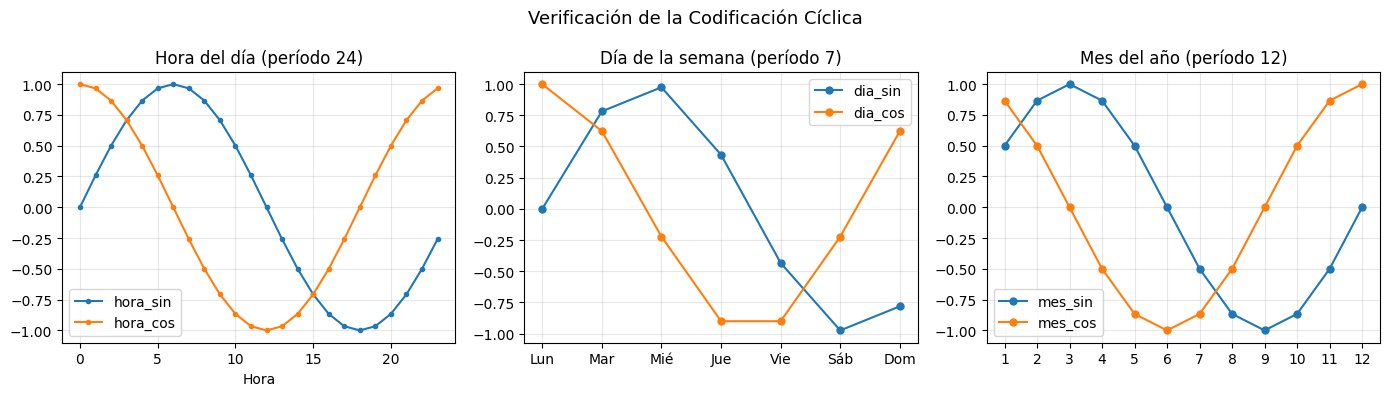


✅ Codificación cíclica aplicada a los tres conjuntos.


In [4]:
print("Ejecutando Paso 3...")

def encode_cyclical(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica codificación seno/coseno a hora, dia_semana y mes.
    Elimina las columnas ordinales originales.
    Devuelve una copia del DataFrame con las nuevas columnas.
    """
    df = df.copy()
    df['hora_sin'] = np.sin(2 * np.pi * df['hora']       / 24)
    df['hora_cos'] = np.cos(2 * np.pi * df['hora']       / 24)
    df['dia_sin']  = np.sin(2 * np.pi * df['dia_semana'] / 7)
    df['dia_cos']  = np.cos(2 * np.pi * df['dia_semana'] / 7)
    df['mes_sin']  = np.sin(2 * np.pi * df['mes']        / 12)
    df['mes_cos']  = np.cos(2 * np.pi * df['mes']        / 12)
    df = df.drop(columns=['hora', 'dia_semana', 'mes'])
    return df

df_train_s = encode_cyclical(df_train_s)
df_val_s   = encode_cyclical(df_val_s)
df_test_s  = encode_cyclical(df_test_s)

# ── Definición del vector de features final ───────────────────────────────────
FEATURE_COLS = (
    SIGNAL_COLS
    + ['hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos', 'es_finde']
)
N_FEATURES = len(FEATURE_COLS)

print(f"Vector de entrada por timestep: {N_FEATURES} features")
print(f"  · Señal física normalizada : {len(SIGNAL_COLS)} (intensidad + ocupación + vmed × 4 sensores)")
print(f"  · Variables cíclicas       : 6  (hora_sin/cos, dia_sin/cos, mes_sin/cos)")
print(f"  · Variable binaria         : 1  (es_finde)")

# ── Visualización de la codificación cíclica (verificación) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Verificación de la Codificación Cíclica", fontsize=13)

horas = np.arange(24)
axes[0].plot(horas, np.sin(2*np.pi*horas/24), label='hora_sin', marker='o', markersize=3)
axes[0].plot(horas, np.cos(2*np.pi*horas/24), label='hora_cos', marker='o', markersize=3)
axes[0].set_title("Hora del día (período 24)")
axes[0].set_xlabel("Hora"); axes[0].legend(); axes[0].grid(alpha=0.3)

dias = np.arange(7)
etiq_dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
axes[1].plot(dias, np.sin(2*np.pi*dias/7), label='dia_sin', marker='o', markersize=5)
axes[1].plot(dias, np.cos(2*np.pi*dias/7), label='dia_cos', marker='o', markersize=5)
axes[1].set_xticks(dias); axes[1].set_xticklabels(etiq_dias)
axes[1].set_title("Día de la semana (período 7)")
axes[1].legend(); axes[1].grid(alpha=0.3)

meses = np.arange(1, 13)
axes[2].plot(meses, np.sin(2*np.pi*meses/12), label='mes_sin', marker='o', markersize=5)
axes[2].plot(meses, np.cos(2*np.pi*meses/12), label='mes_cos', marker='o', markersize=5)
axes[2].set_xticks(meses)
axes[2].set_title("Mes del año (período 12)")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cyclical_encoding_check.png", dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ Codificación cíclica aplicada a los tres conjuntos.")

# Paso 4: Definición de la Clase `M30Dataset`

La clase hereda de `torch.utils.data.Dataset` e implementa la lógica de **ventana deslizante con enfoque Direct Forecasting**:

- **Entrada X:** tensor de forma `(input_len, 19)` con los últimos `input_len` timesteps.
- **Salida y:** escalar con el valor de `intensidad` del sensor objetivo en el instante `t + horizon`.
- **Filtrado de NaNs:** durante la inicialización, se pre-calculan los índices de ventana válidos, descartando aquellos en los que la ventana de entrada o el valor objetivo contengan NaN. Este cálculo se realiza una sola vez y se almacena en `self.valid_indices`.

**Parámetros configurables:**

| Parámetro | Descripción | Valores posibles |
|---|---|---|
| `input_len` | Tamaño de la ventana de entrada | 48 (base) ó 168 (avanzado, solo DL) |
| `horizon` | Pasos hacia el futuro a predecir | 1, 12, 24, 168 |
| `target_col` | Columna de intensidad objetivo | `'intensidad_3820'`, `'intensidad_6642'`, `'intensidad_6676'`, `'intensidad_6782'` |

In [5]:
print("Ejecutando Paso 4...")

class M30Dataset(Dataset):
    """
    Dataset de ventana deslizante para series temporales de tráfico M-30.

    Parámetros
    ----------
    df          : DataFrame ya normalizado y con codificación cíclica aplicada.
    input_len   : Número de timesteps de la ventana de entrada (48 ó 168).
    horizon     : Horizonte de predicción en horas (1, 12, 24 ó 168).
    target_col  : Nombre de la columna de intensidad que se predice.
    feature_cols: Lista ordenada de columnas que forman el tensor de entrada.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        input_len: int,
        horizon: int,
        target_col: str,
        feature_cols: list
    ):
        self.input_len    = input_len
        self.horizon      = horizon
        self.target_col   = target_col
        self.feature_cols = feature_cols

        # Convertimos a arrays numpy para acceso eficiente por índice
        values  = df[feature_cols].values.astype(np.float32)
        targets = df[target_col].values.astype(np.float32)

        # Máscara de NaN: True donde hay al menos un NaN en la fila
        nan_mask = np.isnan(values).any(axis=1) | np.isnan(targets)

        # Pre-cálculo de índices válidos (se ejecuta solo una vez al instanciar)
        self.valid_indices = []
        n = len(df)
        for i in range(n - input_len - horizon + 1):
            window_end = i + input_len
            target_idx = window_end + horizon - 1
            # La ventana de entrada y el timestep objetivo deben estar limpios
            if not nan_mask[i:window_end].any() and not nan_mask[target_idx]:
                self.valid_indices.append(i)

        self.values  = values
        self.targets = targets

        n_total    = n - input_len - horizon + 1
        n_validas  = len(self.valid_indices)
        n_descart  = n_total - n_validas
        print(f"  [{target_col} | input={input_len}h | h={horizon}h] "
              f"Ventanas totales: {n_total} | "
              f"Válidas: {n_validas} | "
              f"Descartadas por NaN: {n_descart} ({100*n_descart/n_total:.1f}%)")

    def __len__(self) -> int:
        """Número de muestras válidas disponibles."""
        return len(self.valid_indices)

    def __getitem__(self, idx: int):
        """
        Devuelve el par (X, y) para el índice idx.

        Returns
        -------
        x : Tensor de forma (input_len, n_features) — ventana de entrada.
        y : Tensor escalar — valor de intensidad en t + horizon.
        """
        i  = self.valid_indices[idx]
        x  = self.values[i : i + self.input_len]                       # (input_len, 19)
        y  = self.targets[i + self.input_len + self.horizon - 1]       # escalar
        return torch.tensor(x), torch.tensor(y)

print("✅ Clase M30Dataset definida correctamente.")

Ejecutando Paso 4...
✅ Clase M30Dataset definida correctamente.


# Paso 5: Construcción de los DataLoaders

Se instancian los tres `DataLoader` con los parámetros de configuración base. **Estos parámetros se modificarán en cada notebook de modelo** según el experimento correspondiente.

> 💡 **Cómo usar este notebook desde los modelos:**  
> Copiar las celdas de los Pasos 1–4 (o importar las funciones) y luego instanciar `M30Dataset` y `DataLoader` con los hiperparámetros propios de cada experimento.

In [6]:
print("Ejecutando Paso 5...")

# ══════════════════════════════════════════════════════════════════════════════
# PARÁMETROS DE CONFIGURACIÓN — modificar aquí para cada experimento
# ══════════════════════════════════════════════════════════════════════════════
INPUT_LEN  = 48               # Ventana de entrada: 48h (base) ó 168h (avanzado DL)
HORIZON    = 1                # Horizonte: 1, 12, 24 ó 168 horas
TARGET_COL = 'intensidad_3820'  # Sensor objetivo
BATCH_SIZE = 32               # Tamaño de batch
# ══════════════════════════════════════════════════════════════════════════════

print(f"\nConfiguración activa:")
print(f"  · Ventana de entrada : {INPUT_LEN} horas")
print(f"  · Horizonte          : {HORIZON} hora(s)")
print(f"  · Variable objetivo  : {TARGET_COL}")
print(f"  · Batch size         : {BATCH_SIZE}")
print(f"  · Features/timestep  : {N_FEATURES}")

# ── Instanciación de los tres Datasets ────────────────────────────────────────
print("\nConstruyendo Datasets (cálculo de ventanas válidas):")
ds_train = M30Dataset(df_train_s, INPUT_LEN, HORIZON, TARGET_COL, FEATURE_COLS)
ds_val   = M30Dataset(df_val_s,   INPUT_LEN, HORIZON, TARGET_COL, FEATURE_COLS)
ds_test  = M30Dataset(df_test_s,  INPUT_LEN, HORIZON, TARGET_COL, FEATURE_COLS)

# ── Instanciación de los tres DataLoaders ─────────────────────────────────────
dl_train = DataLoader(
    ds_train,
    batch_size = BATCH_SIZE,
    shuffle    = False,    # Obligatorio en series temporales
    drop_last  = True      # Batches de tamaño uniforme para estabilidad del gradiente
)
dl_val = DataLoader(
    ds_val,
    batch_size = BATCH_SIZE,
    shuffle    = False,
    drop_last  = False     # Evaluar todas las muestras sin excepción
)
dl_test = DataLoader(
    ds_test,
    batch_size = BATCH_SIZE,
    shuffle    = False,
    drop_last  = False
)

print(f"\n--- Resumen de DataLoaders ---")
print(f"  dl_train → {len(ds_train):>5} muestras | {len(dl_train):>4} batches")
print(f"  dl_val   → {len(ds_val):>5} muestras | {len(dl_val):>4} batches")
print(f"  dl_test  → {len(ds_test):>5} muestras | {len(dl_test):>4} batches")
print("\n✅ Tres DataLoaders construidos y listos.")

Ejecutando Paso 5...

Configuración activa:
  · Ventana de entrada : 48 horas
  · Horizonte          : 1 hora(s)
  · Variable objetivo  : intensidad_3820
  · Batch size         : 32
  · Features/timestep  : 19

Construyendo Datasets (cálculo de ventanas válidas):
  [intensidad_3820 | input=48h | h=1h] Ventanas totales: 16032 | Válidas: 15499 | Descartadas por NaN: 533 (3.3%)
  [intensidad_3820 | input=48h | h=1h] Ventanas totales: 1416 | Válidas: 1284 | Descartadas por NaN: 132 (9.3%)
  [intensidad_3820 | input=48h | h=1h] Ventanas totales: 1368 | Válidas: 1313 | Descartadas por NaN: 55 (4.0%)

--- Resumen de DataLoaders ---
  dl_train → 15499 muestras |  484 batches
  dl_val   →  1284 muestras |   41 batches
  dl_test  →  1313 muestras |   42 batches

✅ Tres DataLoaders construidos y listos.


# Paso 6: Sanity Check y Verificación Dimensional

Verificación de que los tensores tienen la forma, tipo y rango de valores esperados por las arquitecturas LSTM y TCN.

Ejecutando Paso 6...

--- Verificación de formas de tensor ---
  dl_train → X: (32, 48, 19)  y: (32,)
  dl_val   → X: (32, 48, 19)  y: (32,)
  dl_test  → X: (32, 48, 19)  y: (32,)

  Forma esperada X: (32, 48, 19)
  Forma esperada y: (32,)

--- Verificación de NaNs en batch de train ---
  NaNs en X: 0 (esperado: 0)
  NaNs en y: 0 (esperado: 0)

--- Estadísticas del batch de train ---
  X — media: 0.0919 | std: 0.7566 | min: -3.4036 | max: 2.1345
  y — media: -0.1214 | std: 1.2287 | min: -1.6102 | max: 1.7232


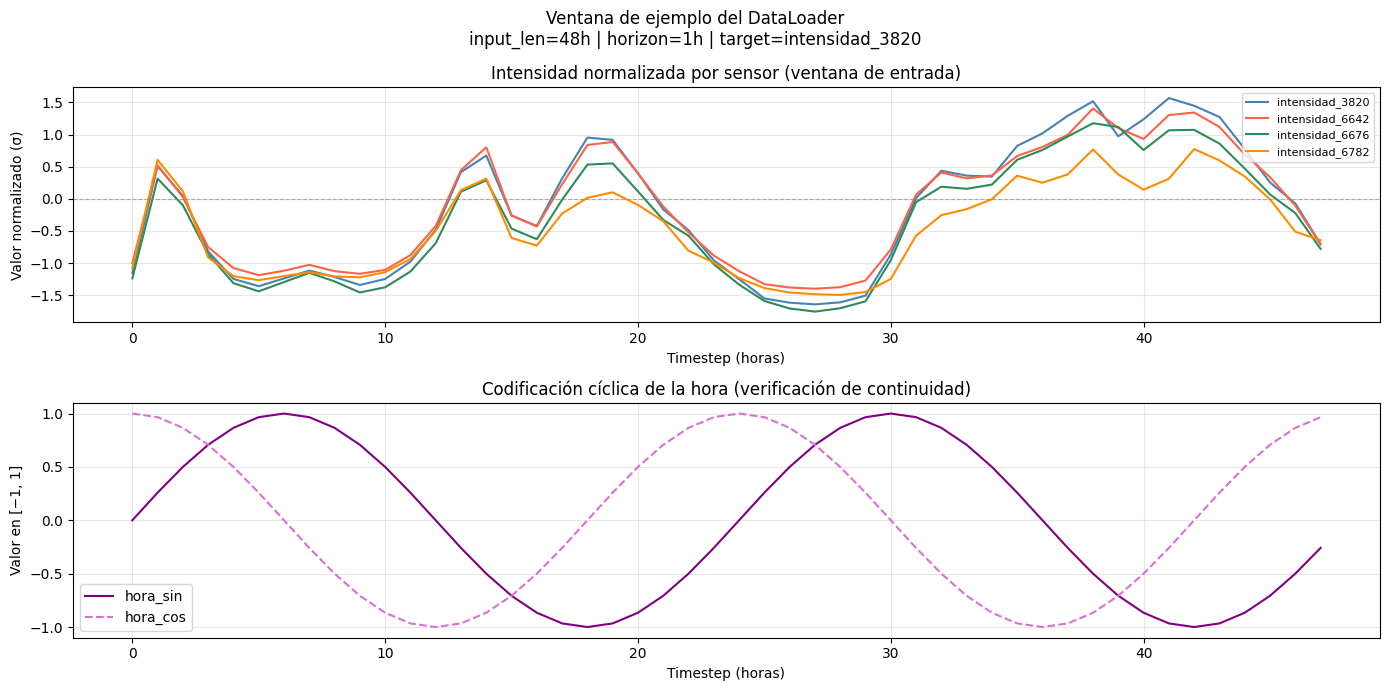


✅ Todos los checks superados.

══════════════════════════════════════════════════════════
   PIPELINE LISTO. Los DataLoaders están disponibles como:
   · dl_train, dl_val, dl_test  (objetos DataLoader)
   · M30Dataset                 (clase reutilizable)
   · scaler                     (guardado en disco como .pkl)
══════════════════════════════════════════════════════════


In [7]:
print("Ejecutando Paso 6...")

# ── Extraer un batch de cada DataLoader ───────────────────────────────────────
x_train, y_train = next(iter(dl_train))
x_val,   y_val   = next(iter(dl_val))
x_test,  y_test  = next(iter(dl_test))

print("\n--- Verificación de formas de tensor ---")
print(f"  dl_train → X: {tuple(x_train.shape)}  y: {tuple(y_train.shape)}")
print(f"  dl_val   → X: {tuple(x_val.shape)}  y: {tuple(y_val.shape)}")
print(f"  dl_test  → X: {tuple(x_test.shape)}  y: {tuple(y_test.shape)}")
print(f"\n  Forma esperada X: ({BATCH_SIZE}, {INPUT_LEN}, {N_FEATURES})")
print(f"  Forma esperada y: ({BATCH_SIZE},)")

assert x_train.shape == (BATCH_SIZE, INPUT_LEN, N_FEATURES), "❌ Forma de X incorrecta"
assert y_train.shape == (BATCH_SIZE,),                        "❌ Forma de y incorrecta"
assert x_train.dtype == torch.float32, "❌ Dtype de X incorrecto"
assert y_train.dtype == torch.float32, "❌ Dtype de y incorrecto"

print("\n--- Verificación de NaNs en batch de train ---")
nan_x = torch.isnan(x_train).sum().item()
nan_y = torch.isnan(y_train).sum().item()
print(f"  NaNs en X: {nan_x} (esperado: 0)")
print(f"  NaNs en y: {nan_y} (esperado: 0)")
assert nan_x == 0 and nan_y == 0, "❌ Se detectaron NaNs en el batch"

print("\n--- Estadísticas del batch de train ---")
print(f"  X — media: {x_train.mean():.4f} | std: {x_train.std():.4f} | "
      f"min: {x_train.min():.4f} | max: {x_train.max():.4f}")
print(f"  y — media: {y_train.mean():.4f} | std: {y_train.std():.4f} | "
      f"min: {y_train.min():.4f} | max: {y_train.max():.4f}")

# ── Visualización de una ventana de ejemplo ───────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle(
    f"Ventana de ejemplo del DataLoader\n"
    f"input_len={INPUT_LEN}h | horizon={HORIZON}h | target={TARGET_COL}",
    fontsize=12
)

# Panel superior: las 4 columnas de intensidad normalizada
idx_intensidad = [FEATURE_COLS.index(c) for c in SIGNAL_COLS if c.startswith('intensidad_')]
colores = ['steelblue', 'tomato', 'seagreen', 'darkorange']
for k, (ci, color) in enumerate(zip(idx_intensidad, colores)):
    axes[0].plot(x_train[0, :, ci].numpy(), label=SIGNAL_COLS[k], color=color, linewidth=1.5)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
axes[0].set_title("Intensidad normalizada por sensor (ventana de entrada)")
axes[0].set_xlabel("Timestep (horas)"); axes[0].set_ylabel("Valor normalizado (σ)")
axes[0].legend(loc='upper right', fontsize=8); axes[0].grid(alpha=0.3)

# Panel inferior: pares cíclicos de hora (verificación)
i_hora_sin = FEATURE_COLS.index('hora_sin')
i_hora_cos = FEATURE_COLS.index('hora_cos')
axes[1].plot(x_train[0, :, i_hora_sin].numpy(), label='hora_sin', color='purple', linewidth=1.5)
axes[1].plot(x_train[0, :, i_hora_cos].numpy(), label='hora_cos', color='orchid',  linewidth=1.5, linestyle='--')
axes[1].set_title("Codificación cíclica de la hora (verificación de continuidad)")
axes[1].set_xlabel("Timestep (horas)"); axes[1].set_ylabel("Valor en [−1, 1]")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dataloader_sample_check.png", dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ Todos los checks superados.")
print("\n══════════════════════════════════════════════════════════")
print("   PIPELINE LISTO. Los DataLoaders están disponibles como:")
print("   · dl_train, dl_val, dl_test  (objetos DataLoader)")
print("   · M30Dataset                 (clase reutilizable)")
print("   · scaler                     (guardado en disco como .pkl)")
print("══════════════════════════════════════════════════════════")

# Anexo: Tabla de Ventanas Válidas por Configuración de Experimento

La siguiente celda calcula cuántas muestras de entrenamiento produce cada combinación de `input_len` × `horizon`. Esta información debe incluirse en la sección de metodología del TFM para documentar el tamaño efectivo de cada experimento.

In [ ]:
# print("Generando tabla de ventanas válidas por configuración...\n")

# INPUT_LENS = [48, 168]
# HORIZONS   = [1, 12, 24, 168]
# SENSORS    = [c for c in FEATURE_COLS if c.startswith('intensidad_')]

# print(f"{'Input':>8} {'Horizon':>9} {'Sensor':>20}  {'Train':>7}  {'Val':>6}  {'Test':>6}")
# print("-" * 65)

# for il in INPUT_LENS:
#     for h in HORIZONS:
#         for sensor in SENSORS:
#             ds_t = M30Dataset(df_train_s, il, h, sensor, FEATURE_COLS)
#             ds_v = M30Dataset(df_val_s,   il, h, sensor, FEATURE_COLS)
#             ds_e = M30Dataset(df_test_s,  il, h, sensor, FEATURE_COLS)
#             print(f"{il:>7}h {h:>8}h {sensor:>20}  {len(ds_t):>7}  {len(ds_v):>6}  {len(ds_e):>6}")
#         print()

Generando tabla de ventanas válidas por configuración...

   Input   Horizon               Sensor    Train     Val    Test
-----------------------------------------------------------------
  [intensidad_3820 | input=48h | h=1h] Ventanas totales: 16032 | Válidas: 15499 | Descartadas por NaN: 533 (3.3%)
  [intensidad_3820 | input=48h | h=1h] Ventanas totales: 1416 | Válidas: 1284 | Descartadas por NaN: 132 (9.3%)
  [intensidad_3820 | input=48h | h=1h] Ventanas totales: 1368 | Válidas: 1313 | Descartadas por NaN: 55 (4.0%)
     48h        1h      intensidad_3820    15499    1284    1313
  [intensidad_6642 | input=48h | h=1h] Ventanas totales: 16032 | Válidas: 15499 | Descartadas por NaN: 533 (3.3%)
  [intensidad_6642 | input=48h | h=1h] Ventanas totales: 1416 | Válidas: 1284 | Descartadas por NaN: 132 (9.3%)
  [intensidad_6642 | input=48h | h=1h] Ventanas totales: 1368 | Válidas: 1313 | Descartadas por NaN: 55 (4.0%)
     48h        1h      intensidad_6642    15499    1284    1313
  [inte